<a href="https://colab.research.google.com/github/oegarza1/6308-data-analytics-assignments/blob/main/Garza_Oscar_DecisionTree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CIDM 6308 — Decision Trees in Python (Churn)
### Student Name: _<type your name here>_

> **Read first**: Review the Python tutorial in Colab before starting. Then complete **Steps 1–6** below. Keep your explanations short and business‑focused. Make sure your final notebook runs top‑to‑bottom without errors.

**Target**: `Churn` (True/False)

---
### Notebook Setup & Submission
1. **File → Save a copy in Drive...**
2. Rename to **`LastName_FirstName_DecisionTree`** (e.g., `Smith_John_DecisionTree`).
3. **Share** → **Anyone with the link** → _Viewer_.
4. Submit your shareable link on Canvas.


## Step 0 — Setup (no points)
**Goal**: Prepare your environment.

**Hints**:
- You will need: `pandas`, `numpy`, `matplotlib.pyplot`,
  `sklearn.model_selection`, `sklearn.tree`, `sklearn.metrics`,
  `sklearn.preprocessing`, `sklearn.compose`, `sklearn.pipeline`.
- Set a dataset URL variable if you are reading from the web.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, export_graphviz, plot_tree, export_text
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                           precision_recall_curve, roc_auc_score, roc_curve, f1_score, precision_score, recall_score)
from sklearn.preprocessing import (StandardScaler, OneHotEncoder)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from tabulate import tabulate
import graphviz
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")


DATA_URL = "https://raw.githubusercontent.com/jtian51/exercise-data/refs/heads/main/telecom_churn_data.csv"
TARGET_COL = "Churn"  # keep as provided by the instructions


## Step 1 — Data Exploration (10 pts)
**Do this**:
1. Load the dataset from the link: https://raw.githubusercontent.com/jtian51/exercise-data/refs/heads/main/telecom_churn_data.csv
2. Show shape, dtypes, and missing values.
3. Show `Churn` distribution (counts and percentages).
4. **Write‑up**: 2–4 sentences with observations (imbalance? data types? missing?).

**Hints**: `pd.read_csv(...)`, `df.shape`, `df.dtypes`, `df.isna().sum()`, `value_counts(normalize=True)`.


In [ ]:
df = pd.read_csv(DATA_URL)

print(df.shape)
display(df.head())
display(df.dtypes)
display(df.isna().sum().sort_values(ascending=False))

# TODO: target distribution
print("\nChurn Count:")
print(df[TARGET_COL].value_counts(dropna=False))

print("\nChurn Percentages:")
print(df[TARGET_COL].value_counts(normalize=True, dropna=False).mul(100))


(3333, 20)


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


,0
State,object
Account length,int64
Area code,int64
International plan,object
Voice mail plan,object
Number vmail messages,int64
Total day minutes,float64
Total day calls,int64
Total day charge,float64
Total eve minutes,float64


,0
State,0
Account length,0
Area code,0
International plan,0
Voice mail plan,0
Number vmail messages,0
Total day minutes,0
Total day calls,0
Total day charge,0
Total eve minutes,0



Churn Count:
Churn
False    2850
True      483
Name: count, dtype: int64

Churn Percentages:
Churn
False    85.508551
True     14.491449
Name: proportion, dtype: float64


> **Write‑up (Step 1)**: The dataset contains 3,333 customer records and 20 columns with numerical, categorical, and Boolean data types. There are no missing values in any of the columns. The target variable is imbalanced: 2,850 customers (85.51%) did not churn, while only 483 customers (14.49%) churned.

## Step 2 — Feature Analysis (10 pts)
**Do this**:
1. Split `X` (features) and `y` (target) (Code for y is preloaded).
2. Encode `y` to binary (`True`→1, `False`→0) [THE CODES ARE PRELOADED].
3. Compute the **top 10** features most correlated with churn.
4. **Write‑up**: 3–5 sentences about which features are most associated with churn and why.

**Hints**: `map`, `select_dtypes`, `pd.get_dummies(..., drop_first=True)`, `corr()`.


In [ ]:
# TODO: create X, y from df[TARGET_COL] using a mapping {True:1, False:0}
X = df.drop(columns=[TARGET_COL])
y = df["Churn"].map({True: 1, False: 0}).astype(int)


# Encode X (one-hot for categoricals; convert any bools in X to 0/1)
X_enc = X.copy()
cat_cols = X_enc.select_dtypes(include=["object", "category"]).columns
X_enc = pd.get_dummies(X_enc, columns=cat_cols, drop_first=True, dtype=int)
bool_cols_X = X_enc.select_dtypes(include=["bool"]).columns
X_enc[bool_cols_X] = X_enc[bool_cols_X].astype(int)


# Create new dataframe for correlation
corr_ready = pd.concat([X_enc, y.rename(y.name)], axis=1)

# TODO: compute correlation with y and show top 10 absolute values
print("\nTop 10 Features Most Correlated with Churn:")
correlations = corr_ready.corr()[TARGET_COL].abs().sort_values(ascending=False)[1:11]
for feature, corr in correlations.items():
    print(f"  {feature}: {corr:.4f}")


Top 10 Features Most Correlated with Churn:
  International plan_Yes: 0.2599
  Customer service calls: 0.2087
  Total day minutes: 0.2052
  Total day charge: 0.2052
  Voice mail plan_Yes: 0.1021
  Total eve minutes: 0.0928
  Total eve charge: 0.0928
  Number vmail messages: 0.0897
  Total intl charge: 0.0683
  Total intl minutes: 0.0682


> **Write‑up (Step 2)**: The feature most strongly associated with customer churn is having an international plan, with an absolute correlation of 0.2599. Customer service calls are also important, suggesting that customers who contact support more frequently may be experiencing unresolved problems that increase their likelihood of leaving. Total day minutes and total day charges show similar correlations because customers with greater daytime usage also tend to have higher charges, which may contribute to dissatisfaction. Voice mail features, evening usage, and international usage have weaker relationships with churn, but they may still provide useful information when combined with the stronger predictors in the decision tree model.

## Step 3 — Train/Test Data Splitting (20 pts)
**Do this**:
1. 80/20 split with **stratify on `y`**.
2. Show shapes and churn rates in train/test.
3. **Write‑up**: 2–3 sentences on why maintaining churn rate balance in both sets is important.

**Hints**: `train_test_split(..., stratify=y, test_size=0.2, random_state=42)`; compare `y.mean()`.


In [ ]:
# TODO: split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# TODO: print/inspect shapes and churn rates
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

print(f"\nTraining set class distribution:")
train_dist = y_train.value_counts(normalize=True)
for i, prop in train_dist.items():
    label = "Non-Churn" if i == 0 else "Churn"
    print(f"  {label}: {prop:.3%}")

print(f"\nTest set class distribution:")
test_dist = y_test.value_counts(normalize=True)
for i, prop in test_dist.items():
    label = "Non-Churn" if i == 0 else "Churn"
    print(f"  {label}: {prop:.3%}")


Training set shape: (2666, 19)
Test set shape: (667, 19)

Training set class distribution:
  Non-Churn: 85.521%
  Churn: 14.479%

Test set class distribution:
  Non-Churn: 85.457%
  Churn: 14.543%


> **Write‑up (Step 3)**: Maintaining a similar churn rate in both the training and test sets ensures that each set accurately represents the original customer population. Because churn is the minority class, stratification prevents one set from containing too few churn cases, which could lead to biased training or misleading evaluation results. The nearly identical churn rates of 14.48% in the training set and 14.54% in the test set confirm that the split preserved the class balance.


## Step 4 — Model Building (20 pts)
**Do this**:
1. Build a pipeline: `ColumnTransformer` (one‑hot on categoricals) → `DecisionTreeClassifier`.
2. Fit on training data.
3. Print tree **depth** and **# leaves**.

**Hints**: `OneHotEncoder(handle_unknown='ignore')`; start with `max_depth=5`; consider `class_weight='balanced'` if imbalanced.


In [ ]:
# TODO: define preprocess with ColumnTransformer using OneHotEncoder on cat_cols
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
preprocess = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            cat_cols
        )
    ],
    remainder="passthrough"
)

# TODO: define a DecisionTreeClassifier
tree = DecisionTreeClassifier(
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

# TODO: build Pipeline and fit
model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("tree", tree)
    ]
)
model.fit(X_train, y_train)

# TODO: inspect trained tree depth and leaves
trained_tree = model.named_steps["tree"]
print(f"Tree depth: {trained_tree.get_depth()}")
print(f"Number of leaves: {trained_tree.get_n_leaves()}")


Tree depth: 5
Number of leaves: 26


> **Write‑up (Step 4)**: The trained decision tree reached the maximum depth of 5 and produced 26 leaves, indicating that it identified several distinct combinations of customer characteristics associated with churn. Each leaf represents a different decision pathway, allowing the model to separate customers into groups with different churn risks.

## Step 5 — Tree Visualization & Analysis (20 pts)
**Do this**:
1. Visualize top levels of the tree.
2. Print readable rules.
3. Show feature importances.
4. **Write‑up**: 4–6 sentences on the business significance of the top churn indicators and decision rules.

**Hints**: `plot_tree(...)`, `export_text(...)`, model’s `feature_names` from the preprocessor, `feature_importances_`.


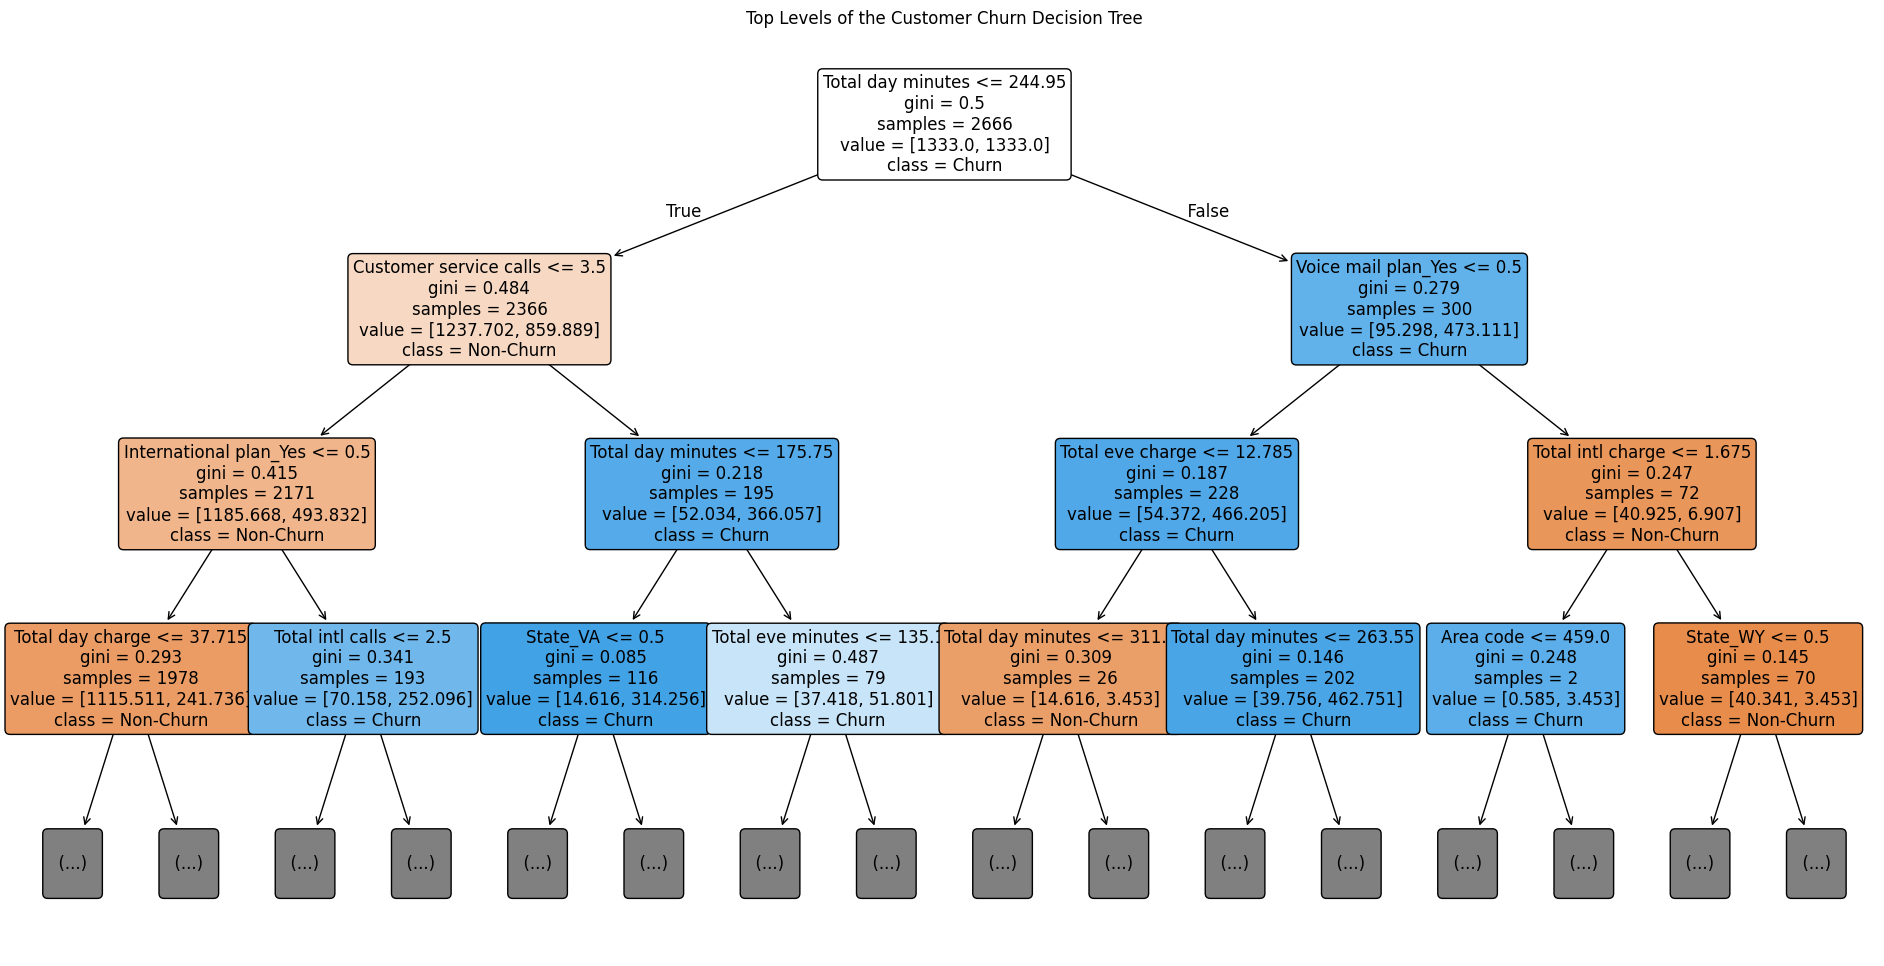


Decision Tree Rules:
|--- Total day minutes <= 244.95
|   |--- Customer service calls <= 3.50
|   |   |--- International plan_Yes <= 0.50
|   |   |   |--- Total day charge <= 37.72
|   |   |   |   |--- Total eve charge <= 27.99
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Total eve charge >  27.99
|   |   |   |   |   |--- class: 1
|   |   |   |--- Total day charge >  37.72
|   |   |   |   |--- Total eve charge <= 20.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Total eve charge >  20.50
|   |   |   |   |   |--- class: 1
|   |   |--- International plan_Yes >  0.50
|   |   |   |--- Total intl calls <= 2.50
|   |   |   |   |--- class: 1
|   |   |   |--- Total intl calls >  2.50
|   |   |   |   |--- Total intl charge <= 3.53
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Total intl charge >  3.53
|   |   |   |   |   |--- class: 1
|   |--- Customer service calls >  3.50
|   |   |--- Total day minutes <= 175.75
|   |   |   |--- State_VA <= 0.50
|   |   |   |   

,Feature,Importance
0,Customer service calls,0.247023
1,International plan_Yes,0.217795
2,Total day minutes,0.209654
3,Total eve charge,0.089474
4,Total intl charge,0.083032
5,Voice mail plan_Yes,0.053939
6,Total day charge,0.041126
7,Total intl calls,0.021899
8,Total eve minutes,0.017219
9,Total night charge,0.005952


In [ ]:
fitted_preprocess = model.named_steps["preprocess"]

feature_names = fitted_preprocess.get_feature_names_out()

clean_feature_names = [
    name.replace("categorical__", "").replace("remainder__", "")
    for name in feature_names
]

plt.figure(figsize=(24, 12))

plot_tree(trained_tree,
          feature_names=clean_feature_names,
          class_names=["Non-Churn", "Churn"],
          filled=True,
          fontsize=12,
          max_depth=3,
          rounded=True)
plt.title("Top Levels of the Customer Churn Decision Tree")
plt.show()


# TODO: export text rules
rules_text = export_text(
    trained_tree,
    feature_names=clean_feature_names,
    decimals=2
)

print("\nDecision Tree Rules:")
print(rules_text[:2000])

# TODO: feature importances (as a Series or DataFrame)
importances = pd.DataFrame({
    "Feature": clean_feature_names,
    "Importance": trained_tree.feature_importances_
})

importances = (
    importances
    .sort_values(by="Importance", ascending=False)
    .reset_index(drop=True)
)

print("\nTop 10 Most Important Features:")
display(importances.head(10))


> **Write‑up (Step 5)**: The model identifies customer service calls, international plan status, and total day minutes as the strongest indicators of customer churn. Total day minutes appear at the first decision split, showing that the amount of daytime usage is a major factor in separating customers with different churn risks. Customers who make more than three customer service calls are frequently placed into higher risk decision paths, which may indicate repeated or unresolved service problems. Having an international plan also increases churn risk in several pathways, particularly when combined with international usage and charge patterns. Evening charges, international charges, and voice mail plan status provide additional information that helps the model refine its predictions. From a business perspective, the company should prioritize retention efforts toward customers with frequent support contacts, high daytime usage, and international plans before they decide to leave.

## Step 6 — Performance Evaluation (20 pts)
**Do this**:
1. Predict on the test set.
2. Compute: **accuracy**, **precision**, **recall**, **confusion matrix**.
3. **Write‑up**: explain what these metrics mean for the telecom customer retention strategy and business impact.

**Hints**: `accuracy_score`, `precision_score`, `recall_score`, `confusion_matrix`, `classification_report`.


In [ ]:
# TODO: predictions and metrics
y_pred = model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("Model Performance:")
print(f"  Accuracy:  {accuracy:.3%}")
print(f"  Precision: {precision:.3%}")
print(f"  Recall:    {recall:.3%}")
print(f"  F1-Score:  {f1:.3%}")

# ... confusion matrix ...
cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Non-Churn", "Actual Churn"],
    columns=["Predicted Non-Churn", "Predicted Churn"]
)

print("\nConfusion Matrix:")
display(cm_df)


Model Performance:
  Accuracy:  90.555%
  Precision: 66.038%
  Recall:    72.165%
  F1-Score:  68.966%

Confusion Matrix:


,Predicted Non-Churn,Predicted Churn
Actual Non-Churn,534,36
Actual Churn,27,70


> **Write‑up (Step 6)**: The decision tree achieved an accuracy of 90.56%, meaning it correctly classified most customers in the test set. Its precision of 66.04% indicates that about two thirds of the customers predicted to churn actually did churn. The recall of 72.16% shows that the model identified 70 of the 97 customers who truly churned, while missing 27 churners. The confusion matrix also shows 36 false positives, meaning some customers were incorrectly flagged as likely to leave. From a business perspective, the model could help the telecom company target retention efforts toward higher risk customers, although some resources may be spent on customers who would not have churned. Because missing an actual churner may result in lost revenue.

---
## Submission Checklist
- [ ] Notebook renamed to **`LastName_FirstName_DecisionTree`**
- [ ] All cells run top‑to‑bottom without errors
- [ ] Short explanations added for each step
- [ ] Share settings: **Anyone with the link → Viewer**
- [ ] Link submitted on Canvas


> **AI Disclosure**: I
used ChatGPT to debug and proofread; ideas and analysis are my own